In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [30]:
# Zero Imputer Class

class ZeroImputerTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns):
        self.columns = columns
        self.learned_median = {}

    def fit(self, X, y=None):
        
        for col in self.columns:
            clean_series = X[col].replace(0, np.nan)
            self.learned_median[col] = clean_series.median()
            
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        
        for col in self.columns:
            X_copy[col] = X_copy[col].replace(0, self.learned_median[col])
            
        return X_copy

In [31]:
df = pd.read_csv("employee_att.csv")
print(df)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

      Age  Income  YratCom  DistFromHome  Overtime  JobSatist  Performance  \
0      61  117569       30             7        46          5            2   
1      51   95783       20            18        14          4            3   
2      37   27324       38            15         8          2            5   
3      30  105289       28             6        48          3            1   
4      43   77958       25            12        14          3            3   
...   ...     ...      ...           ...       ...        ...          ...   
2995   41   24923       17             9        45          2            1   
2996   64  111818       15            10        13          3            5   
2997   23   51241        9            12        16          5            5   
2998   51   36123       39            14        22          5            2   
2999   57   70357       12             1        20          3            5   

     Department      Educ  WorkLifeBalance  Attrition  
0     M

In [32]:
preprocess = ColumnTransformer(
    transformers = [
        ('cat_to_num', OneHotEncoder(), ['Department', 'Educ'])
    ],
    remainder="passthrough"
)


pipeline = Pipeline([
    ('imputer', ZeroImputerTransformer(['Age', 'Income', 'JobSatist', 'Performance', 'WorkLifeBalance'])),
    ('preprocess', preprocess),
    ('preprocessor', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

param_grid = {
    'classifier__n_neighbors' : [3, 5, 7, 9, 11]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [33]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during

In [34]:
predictions = grid_search.predict(X_test)

print(predictions)

[0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 0
 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1
 1 1 0 0 1 0 1 1 1 0 1 1 1 1 0 0 1 0 0 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 0
 1 0 1 1 0 0 1 1 1 1 1 1 

In [35]:
gs_report_df = pd.DataFrame(grid_search.cv_results_)
gs_report = gs_report_df[['param_classifier__n_neighbors', 'mean_test_score', 'std_test_score']]
gs_report = gs_report.sort_values(by='mean_test_score')

best_k = gs_report.iloc[gs_report['param_classifier__n_neighbors'].idxmax()]
worst_k = gs_report.iloc[gs_report['param_classifier__n_neighbors'].idxmin()]


print(gs_report)
print(f"\nBEST K :\n{best_k}")
print(f"\nWORST K :\n{worst_k}")

   param_classifier__n_neighbors  mean_test_score  std_test_score
0                              3         0.669583        0.010992
1                              5         0.684583        0.014044
2                              7         0.689583        0.013502
4                             11         0.694167        0.020216
3                              9         0.699583        0.019293

BEST K :
param_classifier__n_neighbors    9.000000
mean_test_score                  0.699583
std_test_score                   0.019293
Name: 3, dtype: float64

WORST K :
param_classifier__n_neighbors    3.000000
mean_test_score                  0.669583
std_test_score                   0.010992
Name: 0, dtype: float64


In [36]:
print("\n\n",classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix :\n{confusion_matrix(y_test, predictions)}")



               precision    recall  f1-score   support

           0       0.55      0.34      0.42       200
           1       0.72      0.86      0.79       400

    accuracy                           0.69       600
   macro avg       0.64      0.60      0.60       600
weighted avg       0.67      0.69      0.66       600



Confusion Matrix :
[[ 68 132]
 [ 55 345]]


In [37]:
weights = permutation_importance(
    grid_search.best_estimator_,
    X_test,
    y_test,
    scoring='accuracy',
    random_state=42,
    n_repeats=20
)

for col, w in zip(X.columns, weights.importances_mean):
    print(f"{col:30} -- {w:.4f}")

Age                            -- -0.0013
Income                         -- 0.0106
YratCom                        -- 0.0109
DistFromHome                   -- 0.0033
Overtime                       -- 0.0456
JobSatist                      -- 0.0085
Performance                    -- 0.0023
Department                     -- -0.0142
Educ                           -- -0.0219
WorkLifeBalance                -- 0.0029


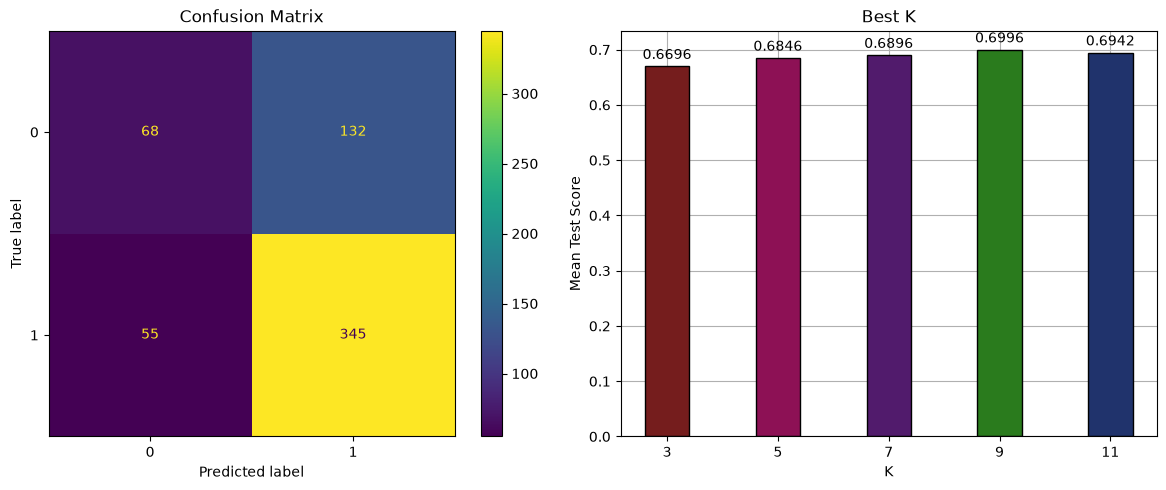

In [38]:
# VISUALIZATION's

fig, axes = plt.subplots(1,2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix")

bar = axes[1].bar(gs_report['param_classifier__n_neighbors'], gs_report['mean_test_score'], color=["#751D1D", "#8D1155", "#511B6C", "#20336C", "#2A7B1D"], edgecolor="#000000")
axes[1].grid(True)
axes[1].set_axisbelow(True)
axes[1].bar_label(bar, padding=3, fmt="%.4f")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Mean Test Score")
axes[1].set_title("Best K")
axes[1].set_xticks(gs_report['param_classifier__n_neighbors'])

plt.tight_layout()
plt.show()